# Multi-Ticker ML Prototype: Stacking Ensemble Architecture
Notebook ini menggunakan arsitektur **Stacking Ensemble Learning** untuk **Klasifikasi Arah Harga (Naik/Turun)** dengan perpaduan data fundamental proksi dan data makro riil (yfinance).

In [37]:
!pip install -q yfinance xgboost scikit-learn pandas numpy matplotlib seaborn

In [38]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

from sklearn.model_selection import TimeSeriesSplit, KFold
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, f1_score, r2_score, mean_absolute_error, mean_squared_error

# Algoritma Stacking Ensemble
from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
import xgboost as xgb

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid')

## 1. Data Loading Multi-Emiten & Data Makro Eksternal
Membaca file `.csv` lokal dan mengunduh data **IHSG** serta **USD/IDR** menggunakan `yfinance`.

In [39]:
# --- Unduh Data Makro Asli (Di luar loop agar efisien) ---
print("Mengunduh data Makro dari yfinance...")
macro_data = yf.download(["USDIDR=X", "^JKSE"], start="2020-01-01", end="2026-01-01")['Close']
# Pastikan urutan kolom tidak terbalik
macro_data = macro_data[['^JKSE', 'USDIDR=X']]
macro_data.columns = ['IHSG_Close', 'USDIDR_Close']
macro_data['USDIDR_Return'] = macro_data['USDIDR_Close'].pct_change()
macro_data['IHSG_Return'] = macro_data['IHSG_Close'].pct_change()

# --- Load Emiten Lokal ---
tickers = ['AMRT', 'ASII', 'BBCA', 'GOTO', 'TLKM']
data_dict = {}

for ticker in tickers:
    filepath = f"data_saham/{ticker}.csv"
    if os.path.exists(filepath):
        df = pd.read_csv(filepath, parse_dates=['date'])
        df = df.set_index('date').sort_index()
        
        if 'close' in df.columns:
            df['Close'] = df['close']
        if 'volume' in df.columns:
            df['Volume'] = df['volume']
            
        data_dict[ticker] = df

print(f"Berhasil memuat {len(data_dict)} emiten lokal.")

[*********************100%***********************]  2 of 2 completed

Mengunduh data Makro dari yfinance...
Berhasil memuat 5 emiten lokal.


## 2. Feature Engineering dengan Data Makro Riil
Menggabungkan indikator teknikal dengan pergerakan makro riil.

In [40]:
def add_features(data, macro_df):
    df = data.copy()
    
    # --- A. Technical & Time-Series Features ---
    df['SMA_10'] = df['Close'].rolling(window=10).mean()
    df['SMA_50'] = df['Close'].rolling(window=50).mean()
    df['SMA_200'] = df['Close'].rolling(window=200).mean() 
    df['Return'] = df['Close'].pct_change()
    df['Volatility_20'] = df['Return'].rolling(window=20).std()
    
    # Proxy Fundamental Analysis
    df['Valuation_Proxy'] = (df['Close'] - df['SMA_200']) / df['SMA_200']
    vol_mean = df['Volume'].rolling(window=50).mean()
    vol_std = df['Volume'].rolling(window=50).std()
    df['Smart_Money_Proxy'] = np.where(df['Volume'] > (vol_mean + 2 * vol_std), 1, 0)
    if 'dividends' in df.columns:
        df['Has_Dividend'] = np.where(df['dividends'] > 0, 1, 0)
    else:
        df['Has_Dividend'] = 0
        
    # Time & Macro Disaster Features
    df['DayOfWeek'] = df.index.dayofweek
    df['Month'] = df.index.month
    
    df['Is_Covid_Crash'] = np.where((df.index >= '2020-02-01') & (df.index <= '2020-06-01'), 1, 0)
    volatility_threshold = df['Volatility_20'].quantile(0.95)
    df['Is_High_Volatility'] = np.where(df['Volatility_20'] > volatility_threshold, 1, 0)
    
    # --- B. Integrasi Data Asli ---
    # Gabungkan data makro asli ke dataframe saham berdasarkan indeks tanggal
    df = df.join(macro_df, how='left')
    
    # Forward fill jika ada hari libur di data makro yang berbeda dengan hari bursa
    df['USDIDR_Return'] = df['USDIDR_Return'].ffill()
    df['IHSG_Return'] = df['IHSG_Return'].ffill()
    
    # NLP Sentiment: Netral 0
    df['Real_Sentiment'] = 0 
    
    # --- C. Target Variable (KLASIFIKASI: NAIK/TURUN) ---
    df['Future_Return'] = df['Return'].shift(-1)
    df['Target_Direction'] = np.where(df['Future_Return'] > 0, 1, 0)
    
    return df.dropna()

# Apply to all tickers
for ticker in data_dict.keys():
    data_dict[ticker] = add_features(data_dict[ticker], macro_data)

## 3. Stacking Ensemble Modeling & Evaluasi Multi-Emiten
Mengevaluasi metrik evaluasi yang komprehensif, mencakup Akurasi, F1 Score, ROC AUC, R-Square, MAE, dan RMSE.

In [41]:
features = ['SMA_10', 'SMA_50', 'Valuation_Proxy', 'Smart_Money_Proxy', 'Has_Dividend', 
            'Return', 'Volatility_20', 'DayOfWeek', 'Month', 'Is_Covid_Crash', 'Is_High_Volatility', 
            'Real_Sentiment', 'USDIDR_Return', 'IHSG_Return']
target = 'Target_Direction'

results = []
stacking_models = {} 

for ticker, df_features in data_dict.items():
    X = df_features[features]
    y = df_features[target]
    
    # Time-Series Split 60/40
    split_idx = int(len(X) * 0.6)
    if split_idx == 0: continue
        
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
    
    if len(y_train.unique()) < 2: continue
    
    # Robust Scaling
    scaler = RobustScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Base Level
    base_models = [
        ('nlp_proxy', MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=200, random_state=42)),
        ('time_series_proxy', RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)),
        ('tabular_engine', xgb.XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.05, eval_metric='logloss', random_state=42))
    ]
    
    meta_model = LogisticRegression()
    stack_clf = StackingClassifier(estimators=base_models, final_estimator=meta_model, cv=5, n_jobs=-1)
    
    # Train
    stack_clf.fit(X_train_scaled, y_train)
    stacking_models[ticker] = stack_clf
    
    # Evaluate
    y_pred = stack_clf.predict(X_test_scaled)
    if len(np.unique(y_test)) > 1:
        y_prob = stack_clf.predict_proba(X_test_scaled)[:, 1]
        auc = roc_auc_score(y_test, y_prob)
    else:
        auc = np.nan
        
    accuracy = accuracy_score(y_test, y_pred) * 100
    f1 = f1_score(y_test, y_pred, average='weighted')
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    results.append({
        'Ticker': ticker,
        'Akurasi Klasifikasi (%)': accuracy,
        'F1 Score': f1,
        'ROC_AUC Score': auc,
        'R-Square': r2,
        'MAE (Error Arah)': mae,
        'RMSE (Error Arah)': rmse
    })

print("Selesai! Metrik komprehensif berhasil dikalkulasi.")

Selesai! Metrik komprehensif berhasil dikalkulasi.


## 4. Tabel Rekapitulasi Metrik Evaluasi
Membandingkan matriks lengkap evaluasi antar emiten setelah menggunakan data makro asli.

,Akurasi Klasifikasi (%),F1 Score,ROC_AUC Score,R-Square,MAE (Error Arah),RMSE (Error Arah)
Ticker,,,,,,
AMRT,47.5779,0.4688,0.4327,-1.1444,0.5242,0.7240
ASII,56.2284,0.4047,0.5475,-0.7785,0.4377,0.6616
BBCA,57.2664,0.4932,0.5098,-0.7499,0.4273,0.6537
GOTO,69.3141,0.5675,0.5221,-0.4427,0.3069,0.5539
TLKM,54.4983,0.3845,0.4866,-0.8349,0.4550,0.6745


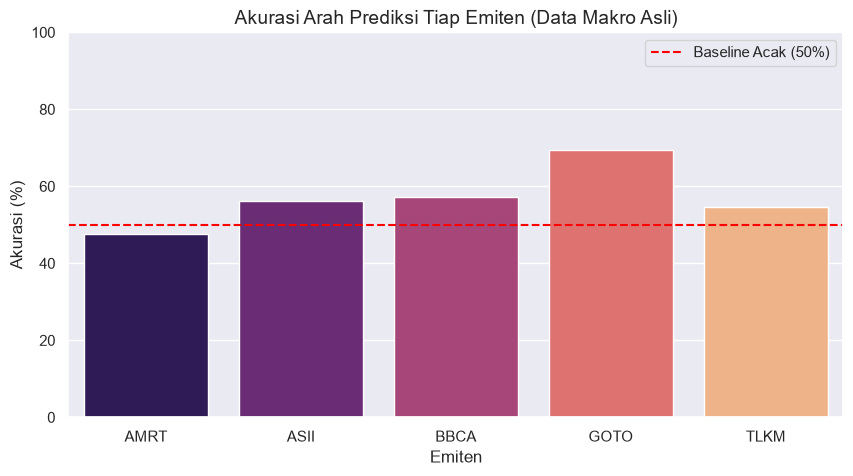

In [42]:
if len(results) > 0:
    df_results = pd.DataFrame(results)
    df_results.set_index('Ticker', inplace=True)
    display(df_results.round(4))

    plt.figure(figsize=(10, 5))
    sns.barplot(x=df_results.index, y=df_results['Akurasi Klasifikasi (%)'], palette='magma')
    plt.axhline(50, color='red', linestyle='--', label='Baseline Acak (50%)')
    plt.title('Akurasi Arah Prediksi Tiap Emiten (Data Makro Asli)', fontsize=14)
    plt.ylabel('Akurasi (%)')
    plt.xlabel('Emiten')
    plt.ylim(0, 100)
    plt.legend()
    plt.show()
else:
    print("Belum ada hasil yang bisa ditampilkan.")